# Chapter 05: Point Estimation

Source span: printed pp. 83-92; PDF pp. 100-109. The source was used for orientation on terminology, section order, and the estimation problems treated in the chapter. The prose, data, diagrams, code, and checks below are original teaching material.

## Chapter Question

How do we estimate a point parameter when the sample space is a circle, where adding a constant angle should rotate the answer but not change the concentration evidence?

The chapter's main computational story is short but subtle. For a von Mises model, the mean direction estimate is the sample resultant direction. The concentration estimate is not a sample variance plugged into a line formula; it is the solution of the Bessel-ratio equation `A(kappa) = Rbar`. Small samples make that concentration estimate fragile. Wrapped Cauchy and mixture models add a second lesson: estimation often becomes an iterative weighting problem on unit vectors, not a least-squares problem on raw angles.

This notebook makes those facts inspectable through a likelihood surface, an inverse-`A` plot, finite-sample bias simulation, wrapped Cauchy weights, mixture responsibilities, and rotation equivariance checks.

## Translation Guide

| Source concept | Computational translation | What to inspect |
| --- | --- | --- |
| Circular parameter | A unit vector or wrapped angle, not an ordinary real number | `wrap_angle` is used before angular differences are compared. |
| Circular unbiasedness | The sine error has mean zero, because direct vector expectation is too strong for a circle-valued estimate | Simulation records `mean_sin_error_mu_hat` instead of pretending angle errors live on a line. |
| von Mises mean MLE | Maximize `sum cos(theta_i - mu)` at the sample resultant direction | The circle panel shows the resultant vector pointing at `mu_hat`. |
| von Mises concentration MLE | Solve `A(kappa) = Rbar`, where `A(kappa) = I_1(kappa) / I_0(kappa)` | The inverse-`A` panel shows `Rbar` meeting the curve at `kappa_hat`. |
| Finite-sample bias | `kappa_hat` is a nonlinear transform of `Rbar`, so small samples can overestimate concentration | Bias curves compare raw and corrected estimates across `n`. |
| Wrapped Cauchy location | Iterative weighted unit-vector equations replace linear residuals | Points near the current direction carry larger weights. |
| von Mises mixture | Responsibilities weight circular likelihood contributions | Each row of the responsibility matrix sums to one. |
| Rotation equivariance | Adding a constant angle to every observation should add the same angle to `mu_hat` and leave `kappa_hat` unchanged | The applied lab rotates the whole sample and checks both claims numerically. |

## Standalone Reading Guide

Point estimation on the circle is mostly a lesson in choosing the right geometry before optimizing. The sample mean direction is not an arithmetic average of angles; it is the argument of the resultant vector after every observation is placed on the unit circle. The resultant length then becomes the data's concentration signal. For the von Mises model, the location estimate follows the resultant direction, while the concentration estimate solves a one-dimensional equation involving the Bessel-ratio function. The notebook makes that split explicit so that location, concentration, and model checking do not blur together.

The likelihood and simulation visuals are meant to be read together. The contour and surface artifacts show where the estimating equations point, while the finite-sample panel shows why raw concentration estimates can be optimistic when the sample is small. The wrapped-Cauchy and mixture sections broaden the chapter from a single symmetric von Mises fit to weighted circular estimation: outlying directions and multiple clusters should affect responsibilities and weights rather than forcing a linear residual story. The rotation lab closes the loop by checking that a legitimate circular estimator rotates with the data and does not depend on the arbitrary zero angle.


In [1]:
from pathlib import Path
import sys


def find_book_root(start: Path) -> Path:
    resolved = start.resolve()
    candidates = [resolved, resolved / "Directional-Statistics", *resolved.parents]
    candidates += [parent / "Directional-Statistics" for parent in resolved.parents]
    for candidate in candidates:
        if (
            (candidate / "AGENTS.md").exists()
            and (candidate / "scripts" / "validate_dirstats_course.py").exists()
            and (candidate / "utils").exists()
        ):
            return candidate
    raise RuntimeError("Could not locate Directional-Statistics course root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-05"
SOURCE_SPAN = {"printed_pages": "83-92", "pdf_pages": "100-109"}
ARTIFACT_DIR = BOOK_ROOT / "artifacts" / TOPIC
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_SPAN

{'printed_pages': '83-92', 'pdf_pages': '100-109'}

In [2]:
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display
from scipy import optimize, special

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.validation import assert_artifacts

TAU = 2.0 * np.pi
np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [3]:
def wrap_angle(theta, center=0.0):
    return (np.asarray(theta) - center + np.pi) % TAU - np.pi + center


def angular_error(a, b):
    return float(wrap_angle(a - b))


def A(kappa):
    kappa = np.asarray(kappa, dtype=float)
    return special.ive(1, kappa) / np.maximum(special.ive(0, kappa), 1e-300)


def A_prime(kappa):
    value = A(kappa)
    return 1.0 - value**2 - value / np.maximum(kappa, 1e-12)


def kappa_initial_guess(rbar):
    r = np.asarray(rbar, dtype=float)
    out = np.empty_like(r, dtype=float)
    low = r < 0.53
    mid = (r >= 0.53) & (r < 0.85)
    high = r >= 0.85
    out[low] = 2 * r[low] + r[low] ** 3 + 5 * r[low] ** 5 / 6
    out[mid] = -0.4 + 1.39 * r[mid] + 0.43 / np.maximum(1 - r[mid], 1e-12)
    out[high] = 1.0 / np.maximum(r[high] ** 3 - 4 * r[high] ** 2 + 3 * r[high], 1e-12)
    return out


def kappa_from_rbar(rbar):
    r = float(np.clip(rbar, 0.0, 0.999999999))
    if r < 1e-10:
        return 0.0
    guess = float(kappa_initial_guess(np.array([r]))[0])
    upper = max(10.0, 4.0 * guess + 1.0)
    while float(A(upper)) <= r:
        upper *= 2.0
    result = optimize.root_scalar(lambda k: float(A(k) - r), bracket=[0.0, upper], xtol=1e-12, rtol=1e-12)
    return float(result.root)


KAPPA_GRID_FOR_INVERSION = np.linspace(0.0, 40.0, 20001)
A_GRID_FOR_INVERSION = A(KAPPA_GRID_FOR_INVERSION)


def kappa_from_rbar_fast(rbar):
    r = np.clip(np.asarray(rbar, dtype=float), 0.0, float(A_GRID_FOR_INVERSION[-1]))
    return np.interp(r, A_GRID_FOR_INVERSION, KAPPA_GRID_FOR_INVERSION)


def best_fisher_correction(khat, n):
    khat = np.asarray(khat, dtype=float)
    low = np.maximum(khat - 2.0 / np.maximum(n * khat, 1e-12), 0.0)
    high = ((n - 1.0) ** 3 * khat) / (n**3 + n)
    return np.where(khat < 2.0, low, high)


def resultant(theta, weights=None):
    theta = np.asarray(theta, dtype=float)
    if weights is None:
        zbar = np.exp(1j * theta).mean()
        total = theta.size
    else:
        w = np.asarray(weights, dtype=float)
        total = np.sum(w)
        zbar = np.sum(w * np.exp(1j * theta)) / total
    return {"C": float(zbar.real), "S": float(zbar.imag), "Rbar": float(abs(zbar)), "mu": float(np.angle(zbar)), "n_eff": float(total)}


def von_mises_pdf(theta, mu, kappa):
    return np.exp(kappa * np.cos(wrap_angle(theta - mu))) / (TAU * special.ive(0, kappa) * np.exp(abs(kappa)))


def vm_loglik(theta, mu, kappa):
    theta = np.asarray(theta, dtype=float)
    return float(kappa * np.sum(np.cos(wrap_angle(theta - mu))) - theta.size * (np.log(TAU) + np.log(special.ive(0, kappa)) + abs(kappa)))


def vm_loglik_grid(theta, mu_grid, kappa_grid):
    cos_sums = np.array([np.sum(np.cos(wrap_angle(theta - mu))) for mu in mu_grid])
    normalizer = np.log(TAU) + np.log(special.ive(0, kappa_grid)) + np.abs(kappa_grid)
    return kappa_grid[:, None] * cos_sums[None, :] - theta.size * normalizer[:, None]


def vm_mle(theta):
    res = resultant(theta)
    khat = kappa_from_rbar(res["Rbar"])
    return {"mu": res["mu"], "kappa": khat, "Rbar": res["Rbar"], "C": res["C"], "S": res["S"]}


def vm_score(theta, mu, kappa):
    score_mu = kappa * np.sum(np.sin(wrap_angle(theta - mu)))
    score_kappa = np.sum(np.cos(wrap_angle(theta - mu))) - theta.size * float(A(kappa))
    return {"score_mu": float(score_mu), "score_kappa": float(score_kappa)}


def wc_p_from_rho_mu(rho, mu):
    return (2.0 * rho / (1.0 + rho**2)) * np.array([np.cos(mu), np.sin(mu)])


def wrapped_cauchy_weights(theta, p_vec):
    x = np.column_stack([np.cos(theta), np.sin(theta)])
    return 1.0 / np.maximum(1.0 - x @ p_vec, 1e-12)


def wc_reweight_path(theta, p0, steps=10):
    x = np.column_stack([np.cos(theta), np.sin(theta)])
    path = [np.asarray(p0, dtype=float)]
    weights = None
    for _ in range(steps):
        weights = 1.0 / np.maximum(1.0 - x @ path[-1], 1e-12)
        p_next = np.sum(weights[:, None] * x, axis=0) / np.sum(weights)
        norm = np.linalg.norm(p_next)
        if norm >= 0.995:
            p_next = p_next / norm * 0.995
        path.append(p_next)
    return np.array(path), weights


def mixture_em_von_mises(theta, n_iter=35):
    theta = np.asarray(theta, dtype=float)
    pi = np.array([0.5, 0.5], dtype=float)
    mu = np.array([-1.7, 1.15], dtype=float)
    kappa = np.array([1.2, 1.2], dtype=float)
    log_history = []
    responsibilities = None
    for _ in range(n_iter):
        weighted_density = np.column_stack([pi[j] * von_mises_pdf(theta, mu[j], kappa[j]) for j in range(2)])
        denom = np.maximum(weighted_density.sum(axis=1, keepdims=True), 1e-300)
        responsibilities = weighted_density / denom
        log_history.append(float(np.sum(np.log(denom[:, 0]))))
        masses = responsibilities.sum(axis=0)
        pi = masses / theta.size
        for j in range(2):
            res = resultant(theta, responsibilities[:, j])
            mu[j] = res["mu"]
            kappa[j] = kappa_from_rbar(res["Rbar"])
    weighted_density = np.column_stack([pi[j] * von_mises_pdf(theta, mu[j], kappa[j]) for j in range(2)])
    responsibilities = weighted_density / np.maximum(weighted_density.sum(axis=1, keepdims=True), 1e-300)
    return {"pi": pi, "mu": mu, "kappa": kappa, "responsibilities": responsibilities, "log_history": np.array(log_history)}

## Von Mises MLE Geometry

For independent observations from a von Mises model, the likelihood separates into a direction part and a concentration part. The direction part is controlled by the resultant vector. Its angle maximizes the cosine sum, so the mean-direction MLE is the sample mean direction. Once that direction is fixed, the concentration score is zero exactly when `A(kappa)` equals the observed mean resultant length `Rbar`.

The figure below puts the computation into four inspection panels:

1. samples on the unit circle with the observed resultant,
2. the Bessel-ratio curve whose inverse gives `kappa_hat`,
3. the likelihood surface near its maximum,
4. finite-sample bias of raw and corrected concentration estimates.

The important visual check is that the same `Rbar` value appears in both the circle panel and the inverse-`A` panel.

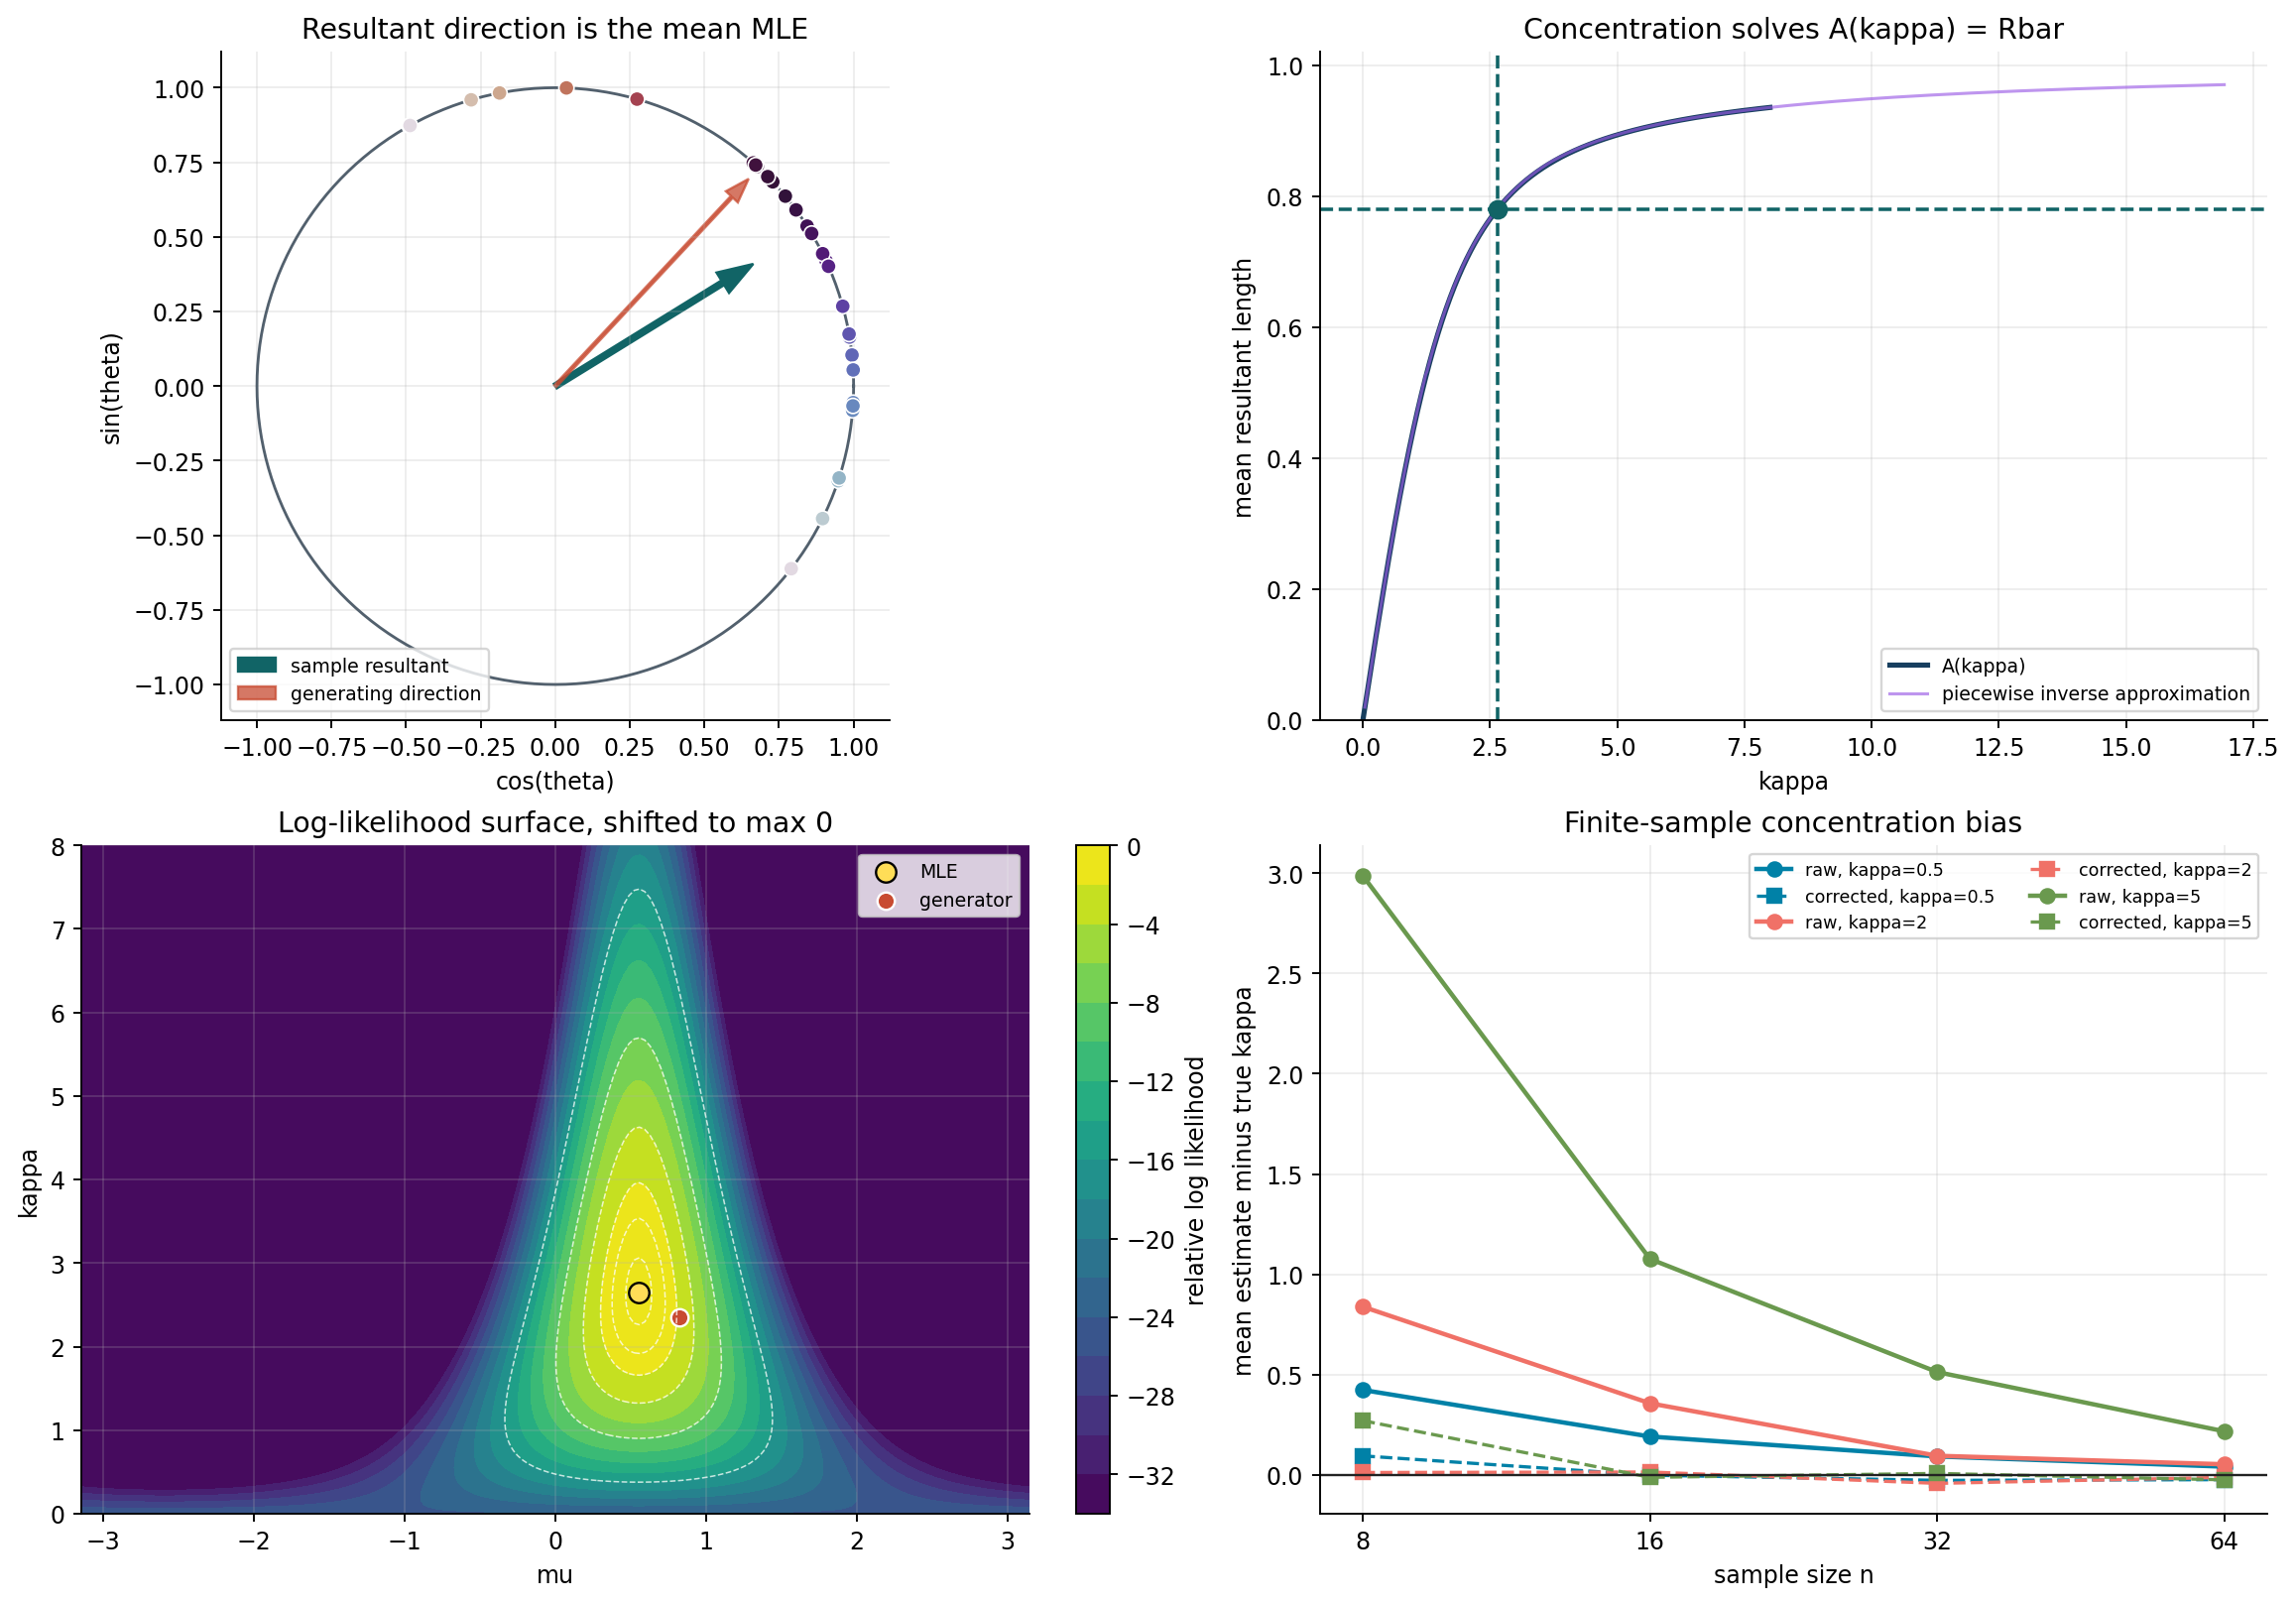

{'n': 32,
 'true_mu': 0.82,
 'true_kappa': 2.35,
 'mu_hat': 0.5527923361647079,
 'kappa_hat': 2.642978741252823,
 'Rbar': 0.7796941588779196,
 'A_kappa_hat': 0.77969415887792,
 'A_matches_Rbar_error': 4.440892098500626e-16,
 'score_mu': -2.3474366817069585e-15,
 'score_kappa': -1.4210854715202004e-14,
 'piecewise_inverse_A_max_error_on_grid': 0.0036964706377526912}

In [4]:
rng = np.random.default_rng(5083)
true_mu = 0.82
true_kappa = 2.35
n_sample = 32
theta = wrap_angle(rng.vonmises(true_mu, true_kappa, n_sample))
mle = vm_mle(theta)
score_at_mle = vm_score(theta, mle["mu"], mle["kappa"])

mu_grid = np.linspace(-np.pi, np.pi, 181)
kappa_grid = np.linspace(0.0, 8.0, 161)
ll_grid = vm_loglik_grid(theta, mu_grid, kappa_grid)
ll_rel = ll_grid - np.max(ll_grid)

sim_rng = np.random.default_rng(5084)
replicates = 700
sample_sizes = np.array([8, 16, 32, 64])
true_kappas_for_bias = np.array([0.5, 2.0, 5.0])
bias_rows = []
for kappa0 in true_kappas_for_bias:
    for n in sample_sizes:
        sim = sim_rng.vonmises(0.0, kappa0, size=(replicates, n))
        zbar = np.exp(1j * sim).mean(axis=1)
        rbar = np.abs(zbar)
        khat = kappa_from_rbar_fast(rbar)
        kcorr = best_fisher_correction(khat, n)
        muhat = np.angle(zbar)
        bias_rows.append({
            "true_kappa": float(kappa0),
            "n": int(n),
            "raw_mean": float(np.mean(khat)),
            "corrected_mean": float(np.mean(kcorr)),
            "raw_bias": float(np.mean(khat) - kappa0),
            "corrected_bias": float(np.mean(kcorr) - kappa0),
            "mean_sin_error_mu_hat": float(np.mean(np.sin(wrap_angle(muhat)))),
        })
bias_df = pd.DataFrame(bias_rows)

fig = plt.figure(figsize=(13.5, 9.4), constrained_layout=True)
grid = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(grid[0, 0])
unit = np.linspace(0, TAU, 361)
ax0.plot(np.cos(unit), np.sin(unit), color="#52606d", lw=1.2)
ax0.scatter(np.cos(theta), np.sin(theta), s=42, c=wrap_angle(theta), cmap="twilight", edgecolor="white", linewidth=0.7, zorder=3)
ax0.arrow(0, 0, mle["Rbar"] * np.cos(mle["mu"]), mle["Rbar"] * np.sin(mle["mu"]),
          width=0.018, head_width=0.08, length_includes_head=True, color="#116466", label="sample resultant")
ax0.arrow(0, 0, 0.95 * np.cos(true_mu), 0.95 * np.sin(true_mu),
          width=0.009, head_width=0.055, length_includes_head=True, color="#c84b31", alpha=0.75, label="generating direction")
ax0.set_title("Resultant direction is the mean MLE")
ax0.set_aspect("equal")
ax0.set_xlim(-1.12, 1.12)
ax0.set_ylim(-1.12, 1.12)
ax0.set_xlabel("cos(theta)")
ax0.set_ylabel("sin(theta)")
ax0.legend(loc="lower left", fontsize=8)

ax1 = fig.add_subplot(grid[0, 1])
k_curve = np.linspace(0.0, 8.0, 500)
ax1.plot(k_curve, A(k_curve), color="#173f5f", lw=2.2, label="A(kappa)")
r_reference = np.linspace(0.02, 0.97, 300)
ax1.plot(kappa_initial_guess(r_reference), r_reference, color="#9b5de5", lw=1.3, alpha=0.65, label="piecewise inverse approximation")
ax1.axhline(mle["Rbar"], color="#116466", ls="--", lw=1.5)
ax1.axvline(mle["kappa"], color="#116466", ls="--", lw=1.5)
ax1.scatter([mle["kappa"]], [mle["Rbar"]], color="#116466", s=55, zorder=5)
ax1.set_title("Concentration solves A(kappa) = Rbar")
ax1.set_xlabel("kappa")
ax1.set_ylabel("mean resultant length")
ax1.set_ylim(0, 1.02)
ax1.legend(loc="lower right", fontsize=8)

ax2 = fig.add_subplot(grid[1, 0])
levels = np.linspace(-34, 0, 18)
cont = ax2.contourf(mu_grid, kappa_grid, np.clip(ll_rel, -34, 0), levels=levels, cmap="viridis")
ax2.contour(mu_grid, kappa_grid, np.clip(ll_rel, -34, 0), levels=[-16, -8, -4, -2, -1, -0.25], colors="white", linewidths=0.65, alpha=0.75)
ax2.scatter([mle["mu"]], [mle["kappa"]], color="#ffdd57", edgecolor="black", s=75, label="MLE")
ax2.scatter([true_mu], [true_kappa], color="#c84b31", edgecolor="white", s=55, label="generator")
ax2.set_title("Log-likelihood surface, shifted to max 0")
ax2.set_xlabel("mu")
ax2.set_ylabel("kappa")
ax2.legend(loc="upper right", fontsize=8)
fig.colorbar(cont, ax=ax2, label="relative log likelihood")

ax3 = fig.add_subplot(grid[1, 1])
colors = {0.5: "#0081a7", 2.0: "#f07167", 5.0: "#6a994e"}
for kappa0 in true_kappas_for_bias:
    part = bias_df[bias_df["true_kappa"] == kappa0]
    ax3.plot(part["n"], part["raw_bias"], marker="o", color=colors[float(kappa0)], lw=1.9, label=f"raw, kappa={kappa0:g}")
    ax3.plot(part["n"], part["corrected_bias"], marker="s", color=colors[float(kappa0)], lw=1.4, ls="--", label=f"corrected, kappa={kappa0:g}")
ax3.axhline(0, color="#222222", lw=1.0)
ax3.set_xscale("log", base=2)
ax3.set_xticks(sample_sizes)
ax3.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax3.set_title("Finite-sample concentration bias")
ax3.set_xlabel("sample size n")
ax3.set_ylabel("mean estimate minus true kappa")
ax3.legend(ncol=2, fontsize=7.4)

mle_panel_path = save_matplotlib(fig, TOPIC, "core", "von-mises-mle-diagnostics.png", dpi=170)
plt.close(fig)

a_curve_error = np.max(np.abs(A(kappa_initial_guess(np.linspace(0.02, 0.97, 200))) - np.linspace(0.02, 0.97, 200)))
vm_diagnostics = {
    "n": int(n_sample),
    "true_mu": float(true_mu),
    "true_kappa": float(true_kappa),
    "mu_hat": float(mle["mu"]),
    "kappa_hat": float(mle["kappa"]),
    "Rbar": float(mle["Rbar"]),
    "A_kappa_hat": float(A(mle["kappa"])),
    "A_matches_Rbar_error": float(abs(A(mle["kappa"]) - mle["Rbar"])),
    "score_mu": score_at_mle["score_mu"],
    "score_kappa": score_at_mle["score_kappa"],
    "piecewise_inverse_A_max_error_on_grid": float(a_curve_error),
}
assert vm_diagnostics["A_matches_Rbar_error"] < 1e-10
assert abs(vm_diagnostics["score_mu"]) < 1e-10
assert abs(vm_diagnostics["score_kappa"]) < 1e-8

display_artifact(mle_panel_path, width=920)
vm_diagnostics

The likelihood panel is deliberately drawn in `(mu, kappa)` coordinates even though the natural parameter is the vector `kappa(cos mu, sin mu)`. That choice makes the chapter's point visible: rotating all observations should slide the surface in the `mu` direction while preserving the concentration coordinate and the maximum value. The next artifact saves the same likelihood as an interactive Plotly surface so the ridge and peak can be inspected without relying on the PDF.

In [5]:
surface = go.Figure(data=[
    go.Surface(
        x=mu_grid,
        y=kappa_grid,
        z=np.clip(ll_rel, -38, 0),
        colorscale="Viridis",
        colorbar={"title": "relative log L"},
        contours={"z": {"show": True, "usecolormap": True, "highlightcolor": "white", "project_z": True}},
        name="relative log likelihood",
    ),
    go.Scatter3d(
        x=[mle["mu"]],
        y=[mle["kappa"]],
        z=[0.0],
        mode="markers+text",
        marker={"size": 5, "color": "#ffdd57", "line": {"color": "black", "width": 1}},
        text=["MLE"],
        textposition="top center",
        name="MLE",
    ),
])
surface.update_layout(
    title="Chapter 05 von Mises likelihood surface",
    scene={
        "xaxis_title": "mu",
        "yaxis_title": "kappa",
        "zaxis_title": "relative log likelihood",
        "camera": {"eye": {"x": 1.5, "y": -1.7, "z": 1.1}},
    },
    margin={"l": 0, "r": 0, "t": 48, "b": 0},
    height=560,
)
likelihood_surface_path = save_plotly_html(surface, TOPIC, "interactive", "von-mises-likelihood-surface.html", include_plotlyjs=True)
assert likelihood_surface_path.exists() and likelihood_surface_path.stat().st_size > 1000
display_artifact(likelihood_surface_path, width="100%", height=560)

## Finite-Sample Behavior

The sample resultant vector is unbiased for the population mean vector, but `kappa_hat` applies a nonlinear inverse to its length. That is why concentration estimation is especially sensitive when `n` is small or the distribution is nearly uniform. The bias panel above shows the usual pattern: the raw concentration MLE tends to sit above the true value for small `n`, and a small-sample correction pulls it back toward zero.

The sine-error column below is a circular unbiasedness diagnostic for `mu_hat`. It should be close to zero across the simulation, because the estimator is centered in direction even though ordinary signed angle errors would depend on the chosen cut point.

In [6]:
bias_display = bias_df.copy()
for column in ["raw_mean", "corrected_mean", "raw_bias", "corrected_bias", "mean_sin_error_mu_hat"]:
    bias_display[column] = bias_display[column].map(lambda x: round(float(x), 4))
display(bias_display)

bias_summary = {
    "replicates_per_cell": int(replicates),
    "sample_sizes": sample_sizes.astype(int).tolist(),
    "true_kappas": true_kappas_for_bias.tolist(),
    "max_abs_mean_sin_error_mu_hat": float(np.max(np.abs(bias_df["mean_sin_error_mu_hat"]))),
    "raw_bias_small_n_kappa_2": float(bias_df[(bias_df["n"] == 8) & (bias_df["true_kappa"] == 2.0)]["raw_bias"].iloc[0]),
    "corrected_bias_small_n_kappa_2": float(bias_df[(bias_df["n"] == 8) & (bias_df["true_kappa"] == 2.0)]["corrected_bias"].iloc[0]),
}
assert bias_summary["max_abs_mean_sin_error_mu_hat"] < 0.08
bias_summary

,true_kappa,n,raw_mean,corrected_mean,raw_bias,corrected_bias,mean_sin_error_mu_hat
0,0.5,8,0.9230,0.5942,0.4230,0.0942,-0.0221
1,0.5,16,0.6907,0.4980,0.1907,-0.0020,-0.0240
2,0.5,32,0.5916,0.4723,0.0916,-0.0277,0.0159
3,0.5,64,0.5407,0.4757,0.0407,-0.0243,0.0048
4,2.0,8,2.8381,2.0113,0.8381,0.0113,0.0007
5,2.0,16,2.3565,2.0139,0.3565,0.0139,0.0026
6,2.0,32,2.0947,1.9571,0.0947,-0.0429,0.0044
7,2.0,64,2.0524,1.9869,0.0524,-0.0131,0.0015
8,5.0,8,7.9875,5.2700,2.9875,0.2700,0.0003
9,5.0,16,6.0764,4.9873,1.0764,-0.0127,-0.0006


{'replicates_per_cell': 700,
 'sample_sizes': [8, 16, 32, 64],
 'true_kappas': [0.5, 2.0, 5.0],
 'max_abs_mean_sin_error_mu_hat': 0.023991244215081475,
 'raw_bias_small_n_kappa_2': 0.8381173557735182,
 'corrected_bias_small_n_kappa_2': 0.011341202358268188}

## Weighted Circular Estimates: Wrapped Cauchy and Mixtures

The later sections of the chapter make the same geometric warning from a different direction. Wrapped Cauchy likelihood equations reweight unit vectors; von Mises mixtures reweight observations by component responsibilities. In both cases the computation is circular because weights multiply unit vectors or densities on the circle. The raw angle values themselves are not residuals on a line.

The next figure has two panels. The left panel follows a wrapped Cauchy reweighting path inside the unit disk. The right panel fits a two-component von Mises mixture by EM and shows the component responsibilities along the circle.

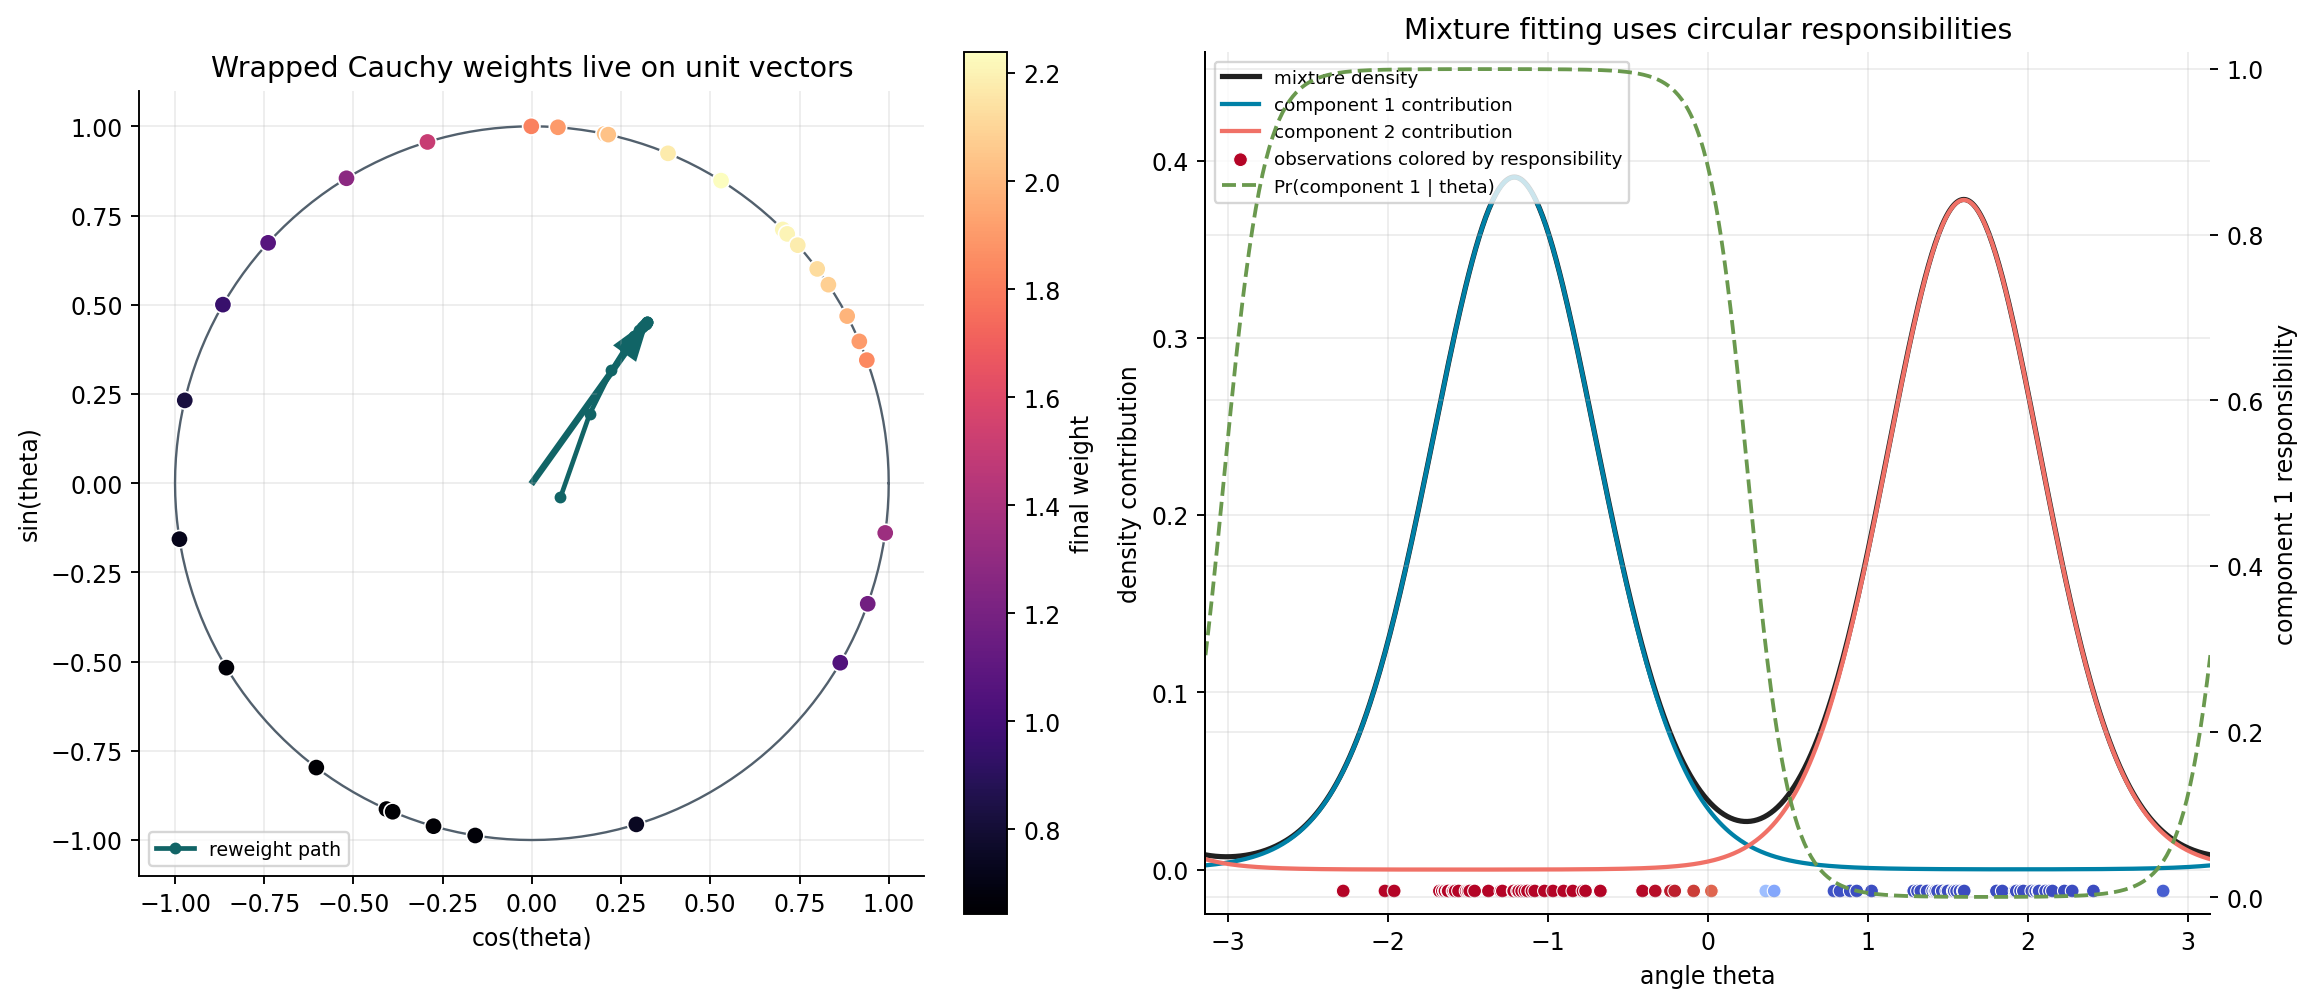

{'wrapped_cauchy_weights_positive': True,
 'wrapped_cauchy_path_inside_unit_disk': True,
 'wrapped_cauchy_final_p_norm': 0.5548703981498988,
 'mixture_weights': [0.526381, 0.473619],
 'mixture_weights_sum': 0.9999999999999999,
 'responsibility_row_sum_max_error': 2.220446049250313e-16,
 'em_loglik_monotone': True,
 'em_loglik_gain': 24.69910583635675}

In [7]:
rng_aux = np.random.default_rng(5091)
wc_theta = wrap_angle(np.concatenate([
    rng_aux.vonmises(0.65, 1.4, 22),
    rng_aux.vonmises(-2.25, 0.45, 8),
]))
wc_path, wc_weights = wc_reweight_path(wc_theta, p0=np.array([0.08, -0.04]), steps=12)

mix_theta = wrap_angle(np.concatenate([
    rng_aux.vonmises(-1.15, 3.2, 48),
    rng_aux.vonmises(1.55, 5.0, 42),
]))
em = mixture_em_von_mises(mix_theta, n_iter=38)
resp = em["responsibilities"]
order = np.argsort(mix_theta)
angle_grid = np.linspace(-np.pi, np.pi, 600)
comp_density = np.column_stack([em["pi"][j] * von_mises_pdf(angle_grid, em["mu"][j], em["kappa"][j]) for j in range(2)])
total_density = comp_density.sum(axis=1)
resp_grid = comp_density[:, 0] / np.maximum(total_density, 1e-300)

fig = plt.figure(figsize=(13.5, 5.8), constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.28])

ax0 = fig.add_subplot(gs[0, 0])
unit = np.linspace(0, TAU, 361)
ax0.plot(np.cos(unit), np.sin(unit), color="#52606d", lw=1.0)
sc = ax0.scatter(np.cos(wc_theta), np.sin(wc_theta), c=wc_weights, cmap="magma", s=54, edgecolor="white", linewidth=0.7, zorder=3)
ax0.plot(wc_path[:, 0], wc_path[:, 1], color="#116466", lw=2.0, marker="o", ms=4, label="reweight path")
ax0.arrow(0, 0, wc_path[-1, 0], wc_path[-1, 1], width=0.012, head_width=0.07, length_includes_head=True, color="#116466")
ax0.set_title("Wrapped Cauchy weights live on unit vectors")
ax0.set_aspect("equal")
ax0.set_xlim(-1.1, 1.1)
ax0.set_ylim(-1.1, 1.1)
ax0.set_xlabel("cos(theta)")
ax0.set_ylabel("sin(theta)")
ax0.legend(loc="lower left", fontsize=8)
fig.colorbar(sc, ax=ax0, label="final weight")

ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(angle_grid, total_density, color="#202020", lw=2.2, label="mixture density")
ax1.plot(angle_grid, comp_density[:, 0], color="#0081a7", lw=1.8, label="component 1 contribution")
ax1.plot(angle_grid, comp_density[:, 1], color="#f07167", lw=1.8, label="component 2 contribution")
ax1.scatter(mix_theta[order], np.full_like(mix_theta, -0.012)[order], c=resp[order, 0], cmap="coolwarm", s=34, edgecolor="white", linewidth=0.45, label="observations colored by responsibility")
ax1_twin = ax1.twinx()
ax1_twin.plot(angle_grid, resp_grid, color="#6a994e", lw=1.6, ls="--", label="Pr(component 1 | theta)")
ax1_twin.set_ylabel("component 1 responsibility")
ax1_twin.set_ylim(-0.02, 1.02)
ax1.set_title("Mixture fitting uses circular responsibilities")
ax1.set_xlabel("angle theta")
ax1.set_ylabel("density contribution")
ax1.set_xlim(-np.pi, np.pi)
ax1.set_ylim(-0.025, max(total_density) * 1.18)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left", fontsize=7.8)

weighted_panel_path = save_matplotlib(fig, TOPIC, "core", "wrapped-cauchy-mixture-responsibilities.png", dpi=170)
plt.close(fig)

weighted_diagnostics = {
    "wrapped_cauchy_weights_positive": bool(np.all(wc_weights > 0)),
    "wrapped_cauchy_path_inside_unit_disk": bool(np.all(np.linalg.norm(wc_path, axis=1) < 1.0)),
    "wrapped_cauchy_final_p_norm": float(np.linalg.norm(wc_path[-1])),
    "mixture_weights": em["pi"].round(6).tolist(),
    "mixture_weights_sum": float(np.sum(em["pi"])),
    "responsibility_row_sum_max_error": float(np.max(np.abs(resp.sum(axis=1) - 1.0))),
    "em_loglik_monotone": bool(np.all(np.diff(em["log_history"]) >= -1e-8)),
    "em_loglik_gain": float(em["log_history"][-1] - em["log_history"][0]),
}
assert weighted_diagnostics["wrapped_cauchy_weights_positive"]
assert weighted_diagnostics["wrapped_cauchy_path_inside_unit_disk"]
assert weighted_diagnostics["responsibility_row_sum_max_error"] < 1e-12
assert abs(weighted_diagnostics["mixture_weights_sum"] - 1.0) < 1e-12
assert weighted_diagnostics["em_loglik_monotone"]

display_artifact(weighted_panel_path, width=920)
weighted_diagnostics

## Applied Lab: Rotate the sample, then refit

A good point-estimation routine on circular data should respect the action of the rotation group. If every observation is moved by the same angle `delta`, the mean-direction estimate should move by `delta`, the concentration estimate should stay fixed, and the likelihood at correspondingly rotated candidate directions should be unchanged.

The lab below runs those checks for several rotations. This is not only a numerical test. It is the computational version of the chapter's geometric contract: the origin of angular coordinates is arbitrary, but the fitted concentration evidence is not.

In [8]:
rotation_rows = []
probe_mu = np.linspace(-2.8, 2.8, 15)
probe_kappa = np.array([0.25, 1.0, mle["kappa"], 5.5])
for delta in np.linspace(-2.4, 2.4, 9):
    rotated = wrap_angle(theta + delta)
    rotated_mle = vm_mle(rotated)
    expected_mu = wrap_angle(mle["mu"] + delta)
    angle_err = angular_error(rotated_mle["mu"], expected_mu)
    kappa_err = rotated_mle["kappa"] - mle["kappa"]
    ll_errors = []
    for mu0 in probe_mu:
        for kappa0 in probe_kappa:
            ll_errors.append(vm_loglik(rotated, wrap_angle(mu0 + delta), kappa0) - vm_loglik(theta, mu0, kappa0))
    rotation_rows.append({
        "delta": float(delta),
        "mu_error": float(angle_err),
        "kappa_error": float(kappa_err),
        "max_likelihood_shift_error": float(np.max(np.abs(ll_errors))),
    })
rotation_df = pd.DataFrame(rotation_rows)
rotation_checks = {
    "max_abs_mu_error": float(np.max(np.abs(rotation_df["mu_error"]))),
    "max_abs_kappa_error": float(np.max(np.abs(rotation_df["kappa_error"]))),
    "max_abs_likelihood_shift_error": float(np.max(np.abs(rotation_df["max_likelihood_shift_error"]))),
}
assert rotation_checks["max_abs_mu_error"] < 1e-10
assert rotation_checks["max_abs_kappa_error"] < 1e-10
assert rotation_checks["max_abs_likelihood_shift_error"] < 1e-10
rotation_lab_path = save_json({"rows": rotation_rows, "checks": rotation_checks}, TOPIC, "checks", "rotation-equivariance-lab.json")
display(rotation_df.round(12))
rotation_checks

,delta,mu_error,kappa_error,max_likelihood_shift_error
0,-2.4,0.0,0.0,0.0
1,-1.8,0.0,0.0,0.0
2,-1.2,-0.0,0.0,0.0
3,-0.6,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0
5,0.6,-0.0,0.0,0.0
6,1.2,-0.0,0.0,0.0
7,1.8,0.0,0.0,0.0
8,2.4,0.0,0.0,0.0


{'max_abs_mu_error': 8.881784197001252e-16,
 'max_abs_kappa_error': 8.881784197001252e-16,
 'max_abs_likelihood_shift_error': 1.1368683772161603e-13}

## Sanity Checks

The final checks gather the mathematical invariants and artifact integrity tests into book-local JSON files. They deliberately check more than file existence: the von Mises score vanishes at the estimate, `A(kappa_hat)` matches `Rbar`, rotation equivariance holds, wrapped Cauchy weights stay positive, mixture responsibilities sum to one, and generated PNGs are nonblank.

In [9]:
from PIL import Image


def image_stats(path):
    with Image.open(path) as img:
        arr = np.asarray(img.convert("RGB"), dtype=float)
    return {
        "path": str(Path(path).resolve().relative_to(BOOK_ROOT)).replace("\\", "/"),
        "width": int(arr.shape[1]),
        "height": int(arr.shape[0]),
        "pixel_std": float(arr.std()),
        "bytes": int(Path(path).stat().st_size),
    }

artifact_paths = [mle_panel_path, likelihood_surface_path, weighted_panel_path, rotation_lab_path]
artifact_records = assert_artifacts(artifact_paths, min_bytes=300)
image_records = [image_stats(mle_panel_path), image_stats(weighted_panel_path)]
assert all(record["pixel_std"] > 1.0 for record in image_records)

point_estimation_checks = {
    "source_span": SOURCE_SPAN,
    "von_mises": vm_diagnostics,
    "finite_sample_bias": bias_summary,
    "wrapped_cauchy_and_mixture": weighted_diagnostics,
    "rotation_equivariance": rotation_checks,
    "image_stats": image_records,
    "all_boolean_checks": {
        "A_kappa_hat_matches_Rbar": vm_diagnostics["A_matches_Rbar_error"] < 1e-10,
        "likelihood_score_small_at_mle": abs(vm_diagnostics["score_mu"]) < 1e-10 and abs(vm_diagnostics["score_kappa"]) < 1e-8,
        "rotation_equivariant": rotation_checks["max_abs_mu_error"] < 1e-10 and rotation_checks["max_abs_kappa_error"] < 1e-10,
        "likelihood_surface_rotates": rotation_checks["max_abs_likelihood_shift_error"] < 1e-10,
        "mixture_responsibilities_sum_to_one": weighted_diagnostics["responsibility_row_sum_max_error"] < 1e-12,
        "wrapped_cauchy_weights_valid": weighted_diagnostics["wrapped_cauchy_weights_positive"] and weighted_diagnostics["wrapped_cauchy_path_inside_unit_disk"],
        "png_artifacts_nonblank": all(record["pixel_std"] > 1.0 for record in image_records),
    },
}
assert all(point_estimation_checks["all_boolean_checks"].values()), point_estimation_checks["all_boolean_checks"]

checks_path = save_json(point_estimation_checks, TOPIC, "checks", "point-estimation-checks.json")
final_sanity = {
    "notebook": "part-01-circular-statistics/chapter-05-point-estimation/05-point-estimation.ipynb",
    "source_span": SOURCE_SPAN,
    "artifacts": artifact_records + assert_artifacts([checks_path], min_bytes=300),
    "checks_path": str(checks_path.resolve().relative_to(BOOK_ROOT)).replace("\\", "/"),
    "core_identity_checks_passed": point_estimation_checks["all_boolean_checks"],
    "pdf_used_for": "orientation only; no source prose, tables, figures, screenshots, or page crops copied",
}
final_sanity_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
assert final_sanity_path.exists() and final_sanity_path.stat().st_size > 300
display_artifact(checks_path)
final_sanity

{'notebook': 'part-01-circular-statistics/chapter-05-point-estimation/05-point-estimation.ipynb',
 'source_span': {'printed_pages': '83-92', 'pdf_pages': '100-109'},
 'artifacts': [{'path': 'artifacts/chapter-05/core/von-mises-mle-diagnostics.png',
   'exists': True,
   'bytes': 333561},
  {'path': 'artifacts/chapter-05/interactive/von-mises-likelihood-surface.html',
   'exists': True,
   'bytes': 5177017},
  {'path': 'artifacts/chapter-05/core/wrapped-cauchy-mixture-responsibilities.png',
   'exists': True,
   'bytes': 245991},
  {'path': 'artifacts/chapter-05/checks/rotation-equivariance-lab.json',
   'exists': True,
   'bytes': 1728},
  {'path': 'artifacts/chapter-05/checks/point-estimation-checks.json',
   'exists': True,
   'bytes': 2296}],
 'checks_path': 'artifacts/chapter-05/checks/point-estimation-checks.json',
 'core_identity_checks_passed': {'A_kappa_hat_matches_Rbar': True,
  'likelihood_score_small_at_mle': True,
  'rotation_equivariant': True,
  'likelihood_surface_rotate

## Takeaways

- The von Mises mean-direction MLE is a direction: it is the angle of the sample resultant vector.
- The von Mises concentration MLE is a root-finding problem: solve `A(kappa) = Rbar`, then verify the likelihood score is small.
- Concentration estimates are biased in small samples because inverse-`A` is nonlinear; simulation makes the size and direction of that bias visible.
- Wrapped Cauchy and mixture estimation replace linear residuals with weights on unit vectors or circular densities.
- Rotation equivariance is a necessary sanity check: changing the angular origin rotates `mu_hat` and leaves `kappa_hat` and the likelihood evidence unchanged.